In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.model_selection import (
    LeaveOneOut,
    KFold,
    GridSearchCV,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [2]:
!git clone https://github.com/lichenyuanidt98/Neurohack_project_HCP.git

Cloning into 'Neurohack_project_HCP'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 41 (delta 1), reused 1 (delta 1), pack-reused 38 (from 1)
Receiving objects: 100% (41/41), 2.11 MiB | 22.46 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [3]:
%cd Neurohack_project_HCP

/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/input/Neurohack_project_HCP


In [4]:
!git pull

Already up to date.


In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
repo_root = Path.cwd()

print("Current directory:")
print(repo_root)

print("\nFiles in repository:")
for path in sorted(repo_root.rglob("*")):
    if path.is_file():
        print(path.relative_to(repo_root))

Current directory:
/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/input/Neurohack_project_HCP

Files in repository:
.git/FETCH_HEAD
.git/HEAD
.git/ORIG_HEAD
.git/config
.git/description
.git/hooks/applypatch-msg.sample
.git/hooks/commit-msg.sample
.git/hooks/fsmonitor-watchman.sample
.git/hooks/post-update.sample
.git/hooks/pre-applypatch.sample
.git/hooks/pre-commit.sample
.git/hooks/pre-merge-commit.sample
.git/hooks/pre-push.sample
.git/hooks/pre-rebase.sample
.git/hooks/pre-receive.sample
.git/hooks/prepare-commit-msg.sample
.git/hooks/push-to-checkout.sample
.git/hooks/sendemail-validate.sample
.git/hooks/update.sample
.git/index
.git/info/exclude
.git/logs/HEAD
.git/logs/refs/heads/main
.git/logs/refs/remotes/origin/HEAD
.git/objects/pack/pack-c12cd15b509711adfea2b66e014dac8eb9f69c9b.idx
.git/objects/pack/pack-c12cd15b509711adfea2b66e014dac8eb9f69c9b.pack
.git/objects/pack/pack-c12cd15b509711adfea2b66e014dac8eb9f69c9b.rev
.git/packed-refs
.git/refs/heads/

In [7]:
csv_files = list(repo_root.rglob("*.csv"))

print(f"Found {len(csv_files)} CSV files:\n")

for path in csv_files:
    print(path.relative_to(repo_root))

Found 34 CSV files:

input/hcp_participant_variables_all.csv
input/sparse_connectomes/sub-100206_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv
input/sparse_connectomes/sub-100307_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv
input/sparse_connectomes/sub-100408_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv
input/sparse_connectomes/sub-100610_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv
input/sparse_connectomes/sub-101006_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv
input/sparse_connectomes/sub-101107_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv
input/sparse_connectomes/sub-101309_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv
input/sparse_connectomes/sub-101410_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv
input/sparse_connectomes/sub-101915_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv
input/sparse_connectomes/sub-102008_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv
input/sparse_connectomes/sub-102109_Glasser_space-MNI152NLin6_res-1x1

In [9]:
print(behavior.columns.tolist())


['Subject', 'Release', 'Acquisition', 'Gender', 'Age', '3T_Full_MR_Compl', 'T1_Count', 'T2_Count', '3T_RS-fMRI_Count', '3T_RS-fMRI_PctCompl', '3T_Full_Task_fMRI', '3T_tMRI_PctCompl', 'fMRI_WM_PctCompl', 'fMRI_Gamb_PctCompl', 'fMRI_Mot_PctCompl', 'fMRI_Lang_PctCompl', 'fMRI_Soc_PctCompl', 'fMRI_Rel_PctCompl', 'fMRI_Emo_PctCompl', '3T_dMRI_Compl', '3T_dMRI_PctCompl', 'dMRI_3T_ReconVrs', 'fMRI_3T_ReconVrs', '7T_Full_MR_Compl', '7T_RS-fMRI_Count', '7T_RS-fMRI_PctCompl', '7T_Full_Task_fMRI', '7T_tMRI_PctCompl', 'fMRI_Movie_Compl', 'fMRI_Movie_PctCompl', 'fMRI_Ret_Compl', 'fMRI_Ret_PctCompl', '7T_dMRI_Compl', '7T_dMRI_PctCompl', '7T_fMRI_Mov_Vrs', 'MEG_AnyData', 'MEG_FullProt_Compl', 'MEG_HeadModel_Avail', 'MEG_CortRibn_Avail', 'MEG_Anatomy_Avail', 'MEG_Anatomy_Compl', 'MEG_Noise_Avail', 'MEG_Noise_Compl', 'MEG_RS_Avail', 'MEG_RS_Compl', 'MEG_WM_Avail', 'MEG_WM_Compl', 'MEG_StoryMath_Avail', 'MEG_StoryMath_Compl', 'MEG_Motor_Avail', 'MEG_Motor_Compl', 'Non-TB_Compl', 'VisProc_Compl', 'DelDis

In [10]:
display(
    behavior[
        [
            "Subject",
            "WM_Task_0bk_Face_Acc",
            "WM_Task_2bk_Face_Acc",
            "face_accuracy",
        ]
    ].head(10)
)

,Subject,WM_Task_0bk_Face_Acc,WM_Task_2bk_Face_Acc,face_accuracy
0,100004,NaN,NaN,NaN
1,100206,100.0,81.25,90.625
2,100307,100.0,93.75,96.875
3,100408,90.0,100.00,95.000
4,100610,100.0,100.00,100.000
5,101006,90.0,81.25,85.625
6,101107,95.0,93.75,94.375
7,101208,NaN,NaN,NaN
8,101309,90.0,81.25,85.625
9,101410,90.0,93.75,91.875


In [13]:
from pathlib import Path

repo_root = Path.cwd()

connectome_dir = repo_root / "input" / "sparse_connectomes"

connectome_files = sorted(
    connectome_dir.glob("sub-*_connectome.csv")
)

print(f"Found {len(connectome_files)} connectome files.")

for file in connectome_files[:5]:
    print(file.name)

Found 30 connectome files.
sub-100206_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv
sub-100307_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv
sub-100408_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv
sub-100610_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv
sub-101006_Glasser_space-MNI152NLin6_res-1x1x1_connectome.csv


In [14]:
import pandas as pd

example = pd.read_csv(
    connectome_files[0],
    sep=r"\s+",
    header=None
)

print("Shape:", example.shape)
display(example.head(10))

Shape: (8320, 3)


,0,1,2
0,1,2,574.0
1,1,3,5913.0
2,1,4,27654.0
3,1,5,19864.0
4,1,6,6422.0
5,1,7,32.0
6,1,8,4.0
7,1,13,8564.0
8,1,14,12.0
9,1,15,2097.0


In [15]:
import re
import pandas as pd

subject_rows = []

for file_path in connectome_files:

    subject_id = re.search(
        r"sub-(\d+)",
        file_path.name,
    ).group(1)

    edges = pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
        names=["node_i", "node_j", "weight"],
    )

    # 每条连接命名，例如 edge_1_2
    edge_names = (
        "edge_"
        + edges["node_i"].astype(str)
        + "_"
        + edges["node_j"].astype(str)
    )

    row = pd.Series(
        edges["weight"].values,
        index=edge_names,
        name=subject_id,
    )

    subject_rows.append(row)

connectome_features = pd.DataFrame(subject_rows)

connectome_features.index.name = "subject_id"
connectome_features = connectome_features.reset_index()

print(connectome_features.shape)
display(connectome_features.head())

(30, 15788)


,subject_id,edge_1_2,edge_1_3,edge_1_4,edge_1_5,edge_1_6,edge_1_7,edge_1_8,edge_1_13,edge_1_14,...,edge_59_129,edge_59_130,edge_59_155,edge_71_160,edge_80_121,edge_80_160,edge_115_127,edge_116_154,edge_116_160,edge_130_180
0,100206,574.0,5913.0,27654.0,19864.0,6422.0,32.0,4.0,8564.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100307,696.0,2816.0,29447.0,21735.0,11079.0,1153.0,7.0,3957.0,120.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100408,5915.0,3441.0,20720.0,13514.0,4743.0,145.0,14.0,4667.0,247.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100610,531.0,2289.0,40204.0,23174.0,11576.0,1106.0,NaN,8503.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,101006,33.0,604.0,16260.0,11686.0,6158.0,1003.0,NaN,2595.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
print(connectome_features.shape)

(30, 15788)


In [18]:
behavior = behavior.rename(
    columns={"Subject": "subject_id"}
)

behavior["subject_id"] = (
    behavior["subject_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
)

print(
    behavior[
        [
            "subject_id",
            "face_accuracy",
        ]
    ].head()
)

  subject_id  face_accuracy
0     100004            NaN
1     100206         90.625
2     100307         96.875
3     100408         95.000
4     100610        100.000


In [19]:
analysis_df = connectome_features.merge(
    behavior[
        [
            "subject_id",
            "face_accuracy",
        ]
    ],
    on="subject_id",
    how="inner",
)

analysis_df = (
    analysis_df
    .dropna(subset=["face_accuracy"])
    .reset_index(drop=True)
)

X = analysis_df.drop(
    columns=[
        "subject_id",
        "face_accuracy",
    ]
)

y = analysis_df["face_accuracy"].astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Subjects:", analysis_df["subject_id"].tolist())

X shape: (29, 15787)
y shape: (29,)
Subjects: ['100206', '100307', '100408', '100610', '101006', '101107', '101309', '101410', '101915', '102008', '102109', '102311', '102513', '102614', '102715', '102816', '103010', '103111', '103212', '103414', '103515', '103818', '104416', '104820', '105014', '105115', '105216', '105620', '105923']


In [20]:
behavior["face_accuracy"] = behavior[
    ["WM_Task_0bk_Face_Acc", "WM_Task_2bk_Face_Acc"]
].mean(axis=1, skipna=False)

In [21]:
behavior[
    [
        "subject_id",
        "face_accuracy",
    ]
]

,subject_id,face_accuracy
0,100004,NaN
1,100206,90.625
2,100307,96.875
3,100408,95.000
4,100610,100.000
...,...,...
1201,992774,81.250
1202,993675,94.375
1203,994273,78.750
1204,995174,96.875


In [22]:
print(behavior[[
    "WM_Task_0bk_Face_Acc",
    "WM_Task_2bk_Face_Acc",
    "face_accuracy"
]].head())

   WM_Task_0bk_Face_Acc  WM_Task_2bk_Face_Acc  face_accuracy
0                   NaN                   NaN            NaN
1                 100.0                 81.25         90.625
2                 100.0                 93.75         96.875
3                  90.0                100.00         95.000
4                 100.0                100.00        100.000


In [23]:
X = analysis_df.drop(columns=["subject_id", "face_accuracy"])
y = analysis_df["face_accuracy"]

In [24]:
import numpy as np
import pandas as pd

X = analysis_df.drop(columns=["subject_id", "face_accuracy"])
y = analysis_df["face_accuracy"].astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Missing X values:", X.isna().sum().sum())
print("Missing y values:", y.isna().sum())

X shape: (29, 15787)
y shape: (29,)
Missing X values: 191996
Missing y values: 0


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.90)),
    ("ridge", Ridge(alpha=1.0))
])

loo = LeaveOneOut()

predictions = np.full(len(y), np.nan)

for train_idx, test_idx in loo.split(X):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]

    pipeline.fit(X_train, y_train)

    predictions[test_idx[0]] = pipeline.predict(X_test)[0]

print("Predictions completed:", np.isfinite(predictions).sum())


/srv/conda/envs/notebook/lib/python3.10/site-packages/sklearn/impute/_base.py:590: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.10/site-packages/sklearn/impute/_base.py:590: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.10/site-packages/sklearn/impute/_base.py:590: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.10/site-p

Predictions completed: 29


In [26]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

r, p_value = pearsonr(y.to_numpy(), predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))
mae = mean_absolute_error(y, predictions)
r2 = r2_score(y, predictions)

print(f"Pearson r: {r:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")

Pearson r: -0.251
P-value: 0.1886
RMSE: 10.499
MAE: 8.270
R²: -0.544


In [28]:
from pathlib import Path

results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)
prediction_results = pd.DataFrame({
    "subject_id": analysis_df["subject_id"],
    "observed_face_accuracy": y,
    "predicted_face_accuracy": predictions,
    "residual": y - predictions
})

display(prediction_results)

prediction_results.to_csv(
    "results/pca_ridge_loocv_predictions.csv",
    index=False
)

,subject_id,observed_face_accuracy,predicted_face_accuracy,residual
0,100206,90.625,95.606147,-4.981147
1,100307,96.875,90.961323,5.913677
2,100408,95.000,89.799006,5.200994
3,100610,100.000,91.460381,8.539619
4,101006,85.625,87.592485,-1.967485
5,101107,94.375,85.834113,8.540887
6,101309,85.625,87.569343,-1.944343
7,101410,91.875,88.211702,3.663298
8,101915,93.750,93.532967,0.217033
9,102008,97.500,85.523587,11.976413


In [29]:
output_path = results_dir / "pca_ridge_loocv_predictions.csv"

prediction_results.to_csv(
    output_path,
    index=False
)

print(f"Saved to: {output_path.resolve()}")

Saved to: /home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/input/Neurohack_project_HCP/results/pca_ridge_loocv_predictions.csv


In [30]:
from pathlib import Path

output_path = Path("results") / "pca_ridge_loocv_predictions.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)

prediction_results.to_csv(output_path, index=False)

print(f"Saved to: {output_path.resolve()}")

Saved to: /home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/input/Neurohack_project_HCP/results/pca_ridge_loocv_predictions.csv


In [31]:
prediction_results = pd.DataFrame({
    "subject_id": analysis_df["subject_id"],
    "observed_face_accuracy": y,
    "predicted_face_accuracy": predictions,
    "residual": y - predictions
})

display(prediction_results)

prediction_results.to_csv(
    "results/pca_ridge_loocv_predictions.csv",
    index=False
)

,subject_id,observed_face_accuracy,predicted_face_accuracy,residual
0,100206,90.625,95.606147,-4.981147
1,100307,96.875,90.961323,5.913677
2,100408,95.000,89.799006,5.200994
3,100610,100.000,91.460381,8.539619
4,101006,85.625,87.592485,-1.967485
5,101107,94.375,85.834113,8.540887
6,101309,85.625,87.569343,-1.944343
7,101410,91.875,88.211702,3.663298
8,101915,93.750,93.532967,0.217033
9,102008,97.500,85.523587,11.976413


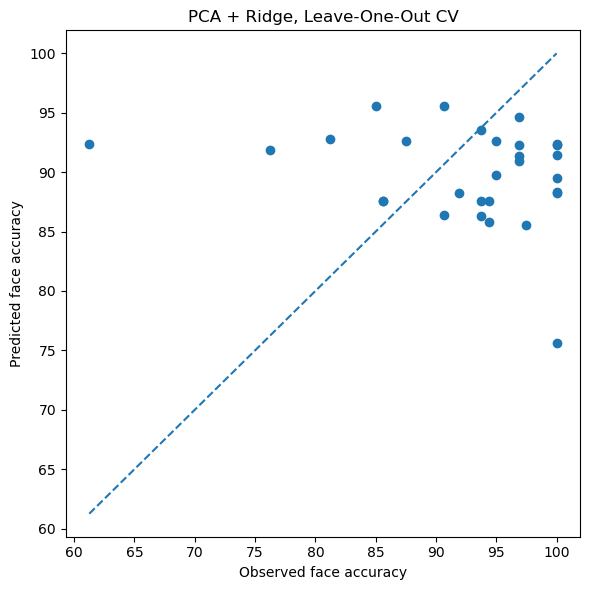

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y, predictions)

lower = min(y.min(), predictions.min())
upper = max(y.max(), predictions.max())

plt.plot([lower, upper], [lower, upper], linestyle="--")

plt.xlabel("Observed face accuracy")
plt.ylabel("Predicted face accuracy")
plt.title("PCA + Ridge, Leave-One-Out CV")
plt.tight_layout()
plt.show()

In [34]:
from pathlib import Path

print(Path.cwd())

/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/input/Neurohack_project_HCP


In [35]:
from pathlib import Path

for f in Path.cwd().iterdir():
    print(f)

/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/input/Neurohack_project_HCP/.git
/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/input/Neurohack_project_HCP/code
/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/input/Neurohack_project_HCP/input
/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/input/Neurohack_project_HCP/results


In [36]:
from pathlib import Path

for f in Path(".").rglob("profiles_all.csv"):
    print(f)
    

In [37]:
from pathlib import Path

for f in Path(".").rglob("profiles_all.csv"):
    print(f)

In [39]:
print(analysis_df.shape)

fa_cols = [c for c in analysis_df.columns if c.endswith("_dki_fa")]

print(len(fa_cols))
print(fa_cols[:10])

(29, 15789)
0
[]


In [42]:
import os
print(os.getcwd())

/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/input/Neurohack_project_HCP


In [43]:
print(os.listdir())

['.git', 'code', 'input', 'results']


In [46]:
profiles = pd.read_csv(
    "/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/input/profiles_all.csv"
)

In [47]:
print(profiles.shape)
print(profiles.columns.tolist()[:50])

(30, 97)
['subject_id', 'ARC_L_dki_awf', 'ARC_L_dki_fa', 'ARC_L_dki_md', 'ARC_L_dki_mk', 'ARC_R_dki_awf', 'ARC_R_dki_fa', 'ARC_R_dki_md', 'ARC_R_dki_mk', 'ATR_L_dki_awf', 'ATR_L_dki_fa', 'ATR_L_dki_md', 'ATR_L_dki_mk', 'ATR_R_dki_awf', 'ATR_R_dki_fa', 'ATR_R_dki_md', 'ATR_R_dki_mk', 'AntFrontal_dki_awf', 'AntFrontal_dki_fa', 'AntFrontal_dki_md', 'AntFrontal_dki_mk', 'CGC_L_dki_awf', 'CGC_L_dki_fa', 'CGC_L_dki_md', 'CGC_L_dki_mk', 'CGC_R_dki_awf', 'CGC_R_dki_fa', 'CGC_R_dki_md', 'CGC_R_dki_mk', 'CST_L_dki_awf', 'CST_L_dki_fa', 'CST_L_dki_md', 'CST_L_dki_mk', 'CST_R_dki_awf', 'CST_R_dki_fa', 'CST_R_dki_md', 'CST_R_dki_mk', 'IFO_L_dki_awf', 'IFO_L_dki_fa', 'IFO_L_dki_md', 'IFO_L_dki_mk', 'IFO_R_dki_awf', 'IFO_R_dki_fa', 'IFO_R_dki_md', 'IFO_R_dki_mk', 'ILF_L_dki_awf', 'ILF_L_dki_fa', 'ILF_L_dki_md', 'ILF_L_dki_mk', 'ILF_R_dki_awf']


In [48]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from scipy.stats import pearsonr

def run_metric(metric):

    cols = [c for c in analysis_df.columns if c.endswith(f"_dki_{metric}")]

    X = analysis_df[cols]
    y = analysis_df["face_accuracy"]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", RidgeCV(alphas=np.logspace(-3,3,50)))
    ])

    pred = cross_val_predict(
        pipeline,
        X,
        y,
        cv=LeaveOneOut()
    )

    r, p = pearsonr(y, pred)

    pipeline.fit(X, y)

    coef = pipeline.named_steps["ridge"].coef_

    importance = (
        pd.DataFrame({
            "tract": cols,
            "weight": coef,
            "abs_weight": np.abs(coef)
        })
        .sort_values("abs_weight", ascending=False)
    )

    return r, p, importance

In [51]:
print(behavior["subject_id"].dtype)
print(profiles["subject_id"].dtype)

object
int64


In [52]:
behavior["subject_id"] = behavior["subject_id"].astype(int)

In [53]:
analysis_df = behavior.merge(
    profiles,
    on="subject_id",
    how="inner"
)

print(analysis_df.shape)

(30, 679)


In [54]:
for metric in ["fa", "md", "mk", "awf"]:
    cols = [c for c in analysis_df.columns if c.endswith(f"_dki_{metric}")]
    print(metric, len(cols))

fa 24
md 24
mk 24
awf 24


In [56]:
print(analysis_df["face_accuracy"].isna().sum())
print(analysis_df["face_accuracy"])

1
0      90.625
1      96.875
2      95.000
3     100.000
4      85.625
5      94.375
6      85.625
7      91.875
8      93.750
9      97.500
10     76.250
11     85.000
12     81.250
13    100.000
14    100.000
15     93.750
16     93.750
17    100.000
18     90.625
19     96.875
20     61.250
21     96.875
22        NaN
23     95.000
24     87.500
25     96.875
26    100.000
27    100.000
28    100.000
29     94.375
Name: face_accuracy, dtype: float64


In [57]:
df = analysis_df[cols + ["face_accuracy"]].dropna()

X = df[cols]
y = df["face_accuracy"]

In [59]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from scipy.stats import pearsonr

def run_metric(metric):

    cols = [c for c in analysis_df.columns if c.endswith(f"_dki_{metric}")]

    # Delete NaN participants
    df = analysis_df[cols + ["face_accuracy"]].dropna()

    X = df[cols]
    y = df["face_accuracy"]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 50)))
    ])

    pred = cross_val_predict(
        pipeline,
        X,
        y,
        cv=LeaveOneOut()
    )

    r, p = pearsonr(y, pred)

    pipeline.fit(X, y)

    coef = pipeline.named_steps["ridge"].coef_

    importance = (
        pd.DataFrame({
            "tract": cols,
            "weight": coef,
            "abs_weight": np.abs(coef)
        })
        .sort_values("abs_weight", ascending=False)
    )

    return r, p, importance

In [60]:
results = {}

for metric in ["fa", "md", "mk", "awf"]:
    r, p, importance = run_metric(metric)
    results[metric] = importance
    print(metric, r, p)

fa -0.1173786691475496 0.5442483938156351
md -0.10894470942222079 0.5737363031797001
mk -0.4311474320089061 0.019538646286087664
awf 0.11575797777497342 0.5498592545907526


In [61]:
results["mk"].head(10)

,tract,weight,abs_weight
5,CGC_L_dki_mk,-0.206818,0.206818
7,CST_L_dki_mk,-0.178165,0.178165
6,CGC_R_dki_mk,-0.173402,0.173402
19,SupFrontal_dki_mk,-0.161840,0.161840
12,ILF_R_dki_mk,-0.155211,0.155211
4,AntFrontal_dki_mk,-0.153179,0.153179
10,IFO_R_dki_mk,-0.150566,0.150566
2,ATR_L_dki_mk,-0.147497,0.147497
0,ARC_L_dki_mk,-0.136027,0.136027
22,UNC_L_dki_mk,-0.129503,0.129503


In [63]:
from cloudpathlib import S3Client

client = S3Client(no_sign_request=True)

root = client.CloudPath("s3://open-neurodata/rokem/hcp1200/afq")

for i, p in enumerate(root.iterdir()):
    print(p)
    if i > 30:
        break

/srv/conda/envs/notebook/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


s3://open-neurodata/rokem/hcp1200/afq/sub-100206
s3://open-neurodata/rokem/hcp1200/afq/sub-100307
s3://open-neurodata/rokem/hcp1200/afq/sub-100408
s3://open-neurodata/rokem/hcp1200/afq/sub-100610
s3://open-neurodata/rokem/hcp1200/afq/sub-101006
s3://open-neurodata/rokem/hcp1200/afq/sub-101107
s3://open-neurodata/rokem/hcp1200/afq/sub-101309
s3://open-neurodata/rokem/hcp1200/afq/sub-101410
s3://open-neurodata/rokem/hcp1200/afq/sub-101915
s3://open-neurodata/rokem/hcp1200/afq/sub-102008
s3://open-neurodata/rokem/hcp1200/afq/sub-102109
s3://open-neurodata/rokem/hcp1200/afq/sub-102311
s3://open-neurodata/rokem/hcp1200/afq/sub-102513
s3://open-neurodata/rokem/hcp1200/afq/sub-102614
s3://open-neurodata/rokem/hcp1200/afq/sub-102715
s3://open-neurodata/rokem/hcp1200/afq/sub-102816
s3://open-neurodata/rokem/hcp1200/afq/sub-103010
s3://open-neurodata/rokem/hcp1200/afq/sub-103111
s3://open-neurodata/rokem/hcp1200/afq/sub-103212
s3://open-neurodata/rokem/hcp1200/afq/sub-103414
s3://open-neurodata/

In [64]:
sub = root / "sub-100206"

for p in sub.iterdir():
    print(p)

s3://open-neurodata/rokem/hcp1200/afq/sub-100206/ses-01


In [65]:
for p in (root / "sub-100206").rglob("*"):
    print(p)

s3://open-neurodata/rokem/hcp1200/afq/sub-100206/ses-01
s3://open-neurodata/rokem/hcp1200/afq/sub-100206/ses-01/ROIs
s3://open-neurodata/rokem/hcp1200/afq/sub-100206/ses-01/sub-100206_dwi_b0.json
s3://open-neurodata/rokem/hcp1200/afq/sub-100206/ses-01/sub-100206_dwi_b0.nii.gz
s3://open-neurodata/rokem/hcp1200/afq/sub-100206/ses-01/sub-100206_dwi_brain_mask.json
s3://open-neurodata/rokem/hcp1200/afq/sub-100206/ses-01/sub-100206_dwi_brain_mask.nii.gz
s3://open-neurodata/rokem/hcp1200/afq/sub-100206/ses-01/sub-100206_dwi_mapping_from-DWI_to_MNI_xfm.nii.gz
s3://open-neurodata/rokem/hcp1200/afq/sub-100206/ses-01/sub-100206_dwi_mapping_reg.json
s3://open-neurodata/rokem/hcp1200/afq/sub-100206/ses-01/sub-100206_dwi_model-CSD_APM.json
s3://open-neurodata/rokem/hcp1200/afq/sub-100206/ses-01/sub-100206_dwi_model-CSD_APM.nii.gz
s3://open-neurodata/rokem/hcp1200/afq/sub-100206/ses-01/sub-100206_dwi_model-CSD_diffmodel.json
s3://open-neurodata/rokem/hcp1200/afq/sub-100206/ses-01/sub-100206_dwi_mode

In [66]:
profile = client.CloudPath(
    "s3://open-neurodata/rokem/hcp1200/afq/sub-100206/ses-01/sub-100206_dwi_space-RASMM_model-CSD_desc-prob-afq_profiles.csv"
)

import pandas as pd

pd.read_csv(profile).head()

,Unnamed: 0,tractID,nodeID,dki_fa,dki_md,dki_mk,dki_awf
0,0,ATR_R,0,0.246921,0.000868,0.501324,0.199983
1,1,ATR_R,1,0.300765,0.000880,0.640582,0.239359
2,2,ATR_R,2,0.339260,0.000917,0.759825,0.271670
3,3,ATR_R,3,0.383969,0.000932,0.830803,0.298200
4,4,ATR_R,4,0.422217,0.000927,0.881660,0.320883


In [67]:
from cloudpathlib import S3Client
from pathlib import Path

client = S3Client(no_sign_request=True)

root = client.CloudPath("s3://open-neurodata/rokem/hcp1200/afq")

subjects = sorted(
    p.name for p in root.iterdir()
    if p.name.startswith("sub-")
)

print(len(subjects))
print(subjects[:5])


1042
['sub-100206', 'sub-100307', 'sub-100408', 'sub-100610', 'sub-101006']


In [68]:
import pandas as pd

def load_subject(subject):

    csv_path = (
        root
        / subject
        / "ses-01"
        / f"{subject}_dwi_space-RASMM_model-CSD_desc-prob-afq_profiles.csv"
    )

    df = pd.read_csv(csv_path)

    # 每条 tract 对 node 求平均
    df = (
        df.groupby("tractID")[["dki_fa","dki_md","dki_mk","dki_awf"]]
        .mean()
    )

    row = {}

    row["subject_id"] = int(subject.replace("sub-",""))

    for tract in df.index:
        row[f"{tract}_dki_fa"] = df.loc[tract,"dki_fa"]
        row[f"{tract}_dki_md"] = df.loc[tract,"dki_md"]
        row[f"{tract}_dki_mk"] = df.loc[tract,"dki_mk"]
        row[f"{tract}_dki_awf"] = df.loc[tract,"dki_awf"]

    return row

In [69]:
rows = []

for i, subject in enumerate(subjects):

    try:
        rows.append(load_subject(subject))
    except Exception as e:
        print(subject, e)

    if (i + 1) % 50 == 0:
        print(i + 1)

50
100
150
200
250
300
350
400
450
500
550
sub-287248 [Errno 2] No such file or directory: '/tmp/tmpxz5ttc_r/open-neurodata/rokem/hcp1200/afq/sub-287248/ses-01/sub-287248_dwi_space-RASMM_model-CSD_desc-prob-afq_profiles.csv'
600
650
700
750
800
850
900
950
1000


In [70]:
profiles_all = pd.DataFrame(rows)

profiles_all.shape

(1041, 97)

In [71]:
profiles_all.to_csv(
    "profiles_all_complete.csv",
    index=False
)

In [72]:
analysis_df = behavior.merge(
    profiles_all,
    on="subject_id"
)

In [73]:
from pathlib import Path

print(Path.cwd())

/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/input/Neurohack_project_HCP


In [74]:
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import pearsonr

from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [75]:
# File paths

PROJECT_ROOT = Path(
    "/home/jovyan/curriculum/"
    "rokem-benson-datashowcase/"
    "Neurohack_project_HCP"
)

BEHAVIOR_PATH = (
    PROJECT_ROOT
    / "input"
    / "hcp_participant_variables_all.csv"
)

PROFILES_PATH = (
    PROJECT_ROOT
    / "input"
    / "Neurohack_project_HCP"
    / "profiles_all_complete.csv"
)

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Behavior file exists:", BEHAVIOR_PATH.exists())
print("Profiles file exists:", PROFILES_PATH.exists())

print("\nBehavior path:")
print(BEHAVIOR_PATH)

print("\nProfiles path:")
print(PROFILES_PATH)

Behavior file exists: True
Profiles file exists: True

Behavior path:
/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/input/hcp_participant_variables_all.csv

Profiles path:
/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/input/Neurohack_project_HCP/profiles_all_complete.csv


In [76]:
profiles = pd.read_csv(PROFILES_PATH)

print("Profiles shape:", profiles.shape)
print("Number of columns:", profiles.shape[1])

display(profiles.head())

Profiles shape: (1041, 97)
Number of columns: 97


,subject_id,ARC_L_dki_fa,ARC_L_dki_md,ARC_L_dki_mk,ARC_L_dki_awf,ARC_R_dki_fa,ARC_R_dki_md,ARC_R_dki_mk,ARC_R_dki_awf,ATR_L_dki_fa,...,Temporal_dki_mk,Temporal_dki_awf,UNC_L_dki_fa,UNC_L_dki_md,UNC_L_dki_mk,UNC_L_dki_awf,UNC_R_dki_fa,UNC_R_dki_md,UNC_R_dki_mk,UNC_R_dki_awf
0,100206,0.519745,0.000861,1.100742,0.421363,0.454448,0.000865,1.074295,0.385349,0.446800,...,1.056521,0.420159,0.463728,0.000956,0.995955,0.341059,0.472889,0.000942,0.988601,0.345566
1,100307,0.534278,0.000846,1.034379,0.409483,0.436614,0.000918,0.996136,0.363971,0.446175,...,0.976830,0.394212,0.432646,0.000993,0.895127,0.313045,0.442562,0.000971,0.915798,0.314696
2,100408,0.530353,0.000809,1.077789,0.410723,0.473366,0.000839,1.084796,0.391698,0.494189,...,0.978209,0.393830,0.442300,0.000934,1.014236,0.338719,0.448725,0.000890,1.028878,0.337252
3,100610,0.475449,0.000947,1.032356,0.378108,0.459758,0.000870,1.048489,0.374543,0.464517,...,1.009254,0.382705,0.443042,0.000996,0.956977,0.321521,0.436237,0.000974,0.977282,0.324201
4,101006,0.486592,0.000846,1.032577,0.378181,0.434698,0.000889,1.033587,0.366175,0.482249,...,0.962131,0.368304,0.409050,0.000944,0.965962,0.319666,0.407525,0.000932,1.004965,0.326942


In [77]:
for column in profiles.columns:
    print(column)

subject_id
ARC_L_dki_fa
ARC_L_dki_md
ARC_L_dki_mk
ARC_L_dki_awf
ARC_R_dki_fa
ARC_R_dki_md
ARC_R_dki_mk
ARC_R_dki_awf
ATR_L_dki_fa
ATR_L_dki_md
ATR_L_dki_mk
ATR_L_dki_awf
ATR_R_dki_fa
ATR_R_dki_md
ATR_R_dki_mk
ATR_R_dki_awf
AntFrontal_dki_fa
AntFrontal_dki_md
AntFrontal_dki_mk
AntFrontal_dki_awf
CGC_L_dki_fa
CGC_L_dki_md
CGC_L_dki_mk
CGC_L_dki_awf
CGC_R_dki_fa
CGC_R_dki_md
CGC_R_dki_mk
CGC_R_dki_awf
CST_L_dki_fa
CST_L_dki_md
CST_L_dki_mk
CST_L_dki_awf
CST_R_dki_fa
CST_R_dki_md
CST_R_dki_mk
CST_R_dki_awf
IFO_L_dki_fa
IFO_L_dki_md
IFO_L_dki_mk
IFO_L_dki_awf
IFO_R_dki_fa
IFO_R_dki_md
IFO_R_dki_mk
IFO_R_dki_awf
ILF_L_dki_fa
ILF_L_dki_md
ILF_L_dki_mk
ILF_L_dki_awf
ILF_R_dki_fa
ILF_R_dki_md
ILF_R_dki_mk
ILF_R_dki_awf
Motor_dki_fa
Motor_dki_md
Motor_dki_mk
Motor_dki_awf
Occipital_dki_fa
Occipital_dki_md
Occipital_dki_mk
Occipital_dki_awf
Orbital_dki_fa
Orbital_dki_md
Orbital_dki_mk
Orbital_dki_awf
PostParietal_dki_fa
PostParietal_dki_md
PostParietal_dki_mk
PostParietal_dki_awf
SLF_L_dki_fa
SLF

In [78]:
print("Subject ID column present:", "subject_id" in profiles.columns)

if "subject_id" in profiles.columns:
    print("Unique subjects:", profiles["subject_id"].nunique())
    print("Duplicate subject IDs:", profiles["subject_id"].duplicated().sum())
    print("Missing subject IDs:", profiles["subject_id"].isna().sum())

Subject ID column present: True
Unique subjects: 1041
Duplicate subject IDs: 0
Missing subject IDs: 0


In [79]:
for metric in ["fa", "md", "mk", "awf"]:
    columns = [
        column
        for column in profiles.columns
        if column.endswith(f"_dki_{metric}")
    ]

    print(
        metric.upper(),
        "features:",
        len(columns),
    )

    print(columns[:5])
    print()

FA features: 24
['ARC_L_dki_fa', 'ARC_R_dki_fa', 'ATR_L_dki_fa', 'ATR_R_dki_fa', 'AntFrontal_dki_fa']

MD features: 24
['ARC_L_dki_md', 'ARC_R_dki_md', 'ATR_L_dki_md', 'ATR_R_dki_md', 'AntFrontal_dki_md']

MK features: 24
['ARC_L_dki_mk', 'ARC_R_dki_mk', 'ATR_L_dki_mk', 'ATR_R_dki_mk', 'AntFrontal_dki_mk']

AWF features: 24
['ARC_L_dki_awf', 'ARC_R_dki_awf', 'ATR_L_dki_awf', 'ATR_R_dki_awf', 'AntFrontal_dki_awf']



In [80]:
behavior = pd.read_csv(BEHAVIOR_PATH)

print("Behavioral data shape:", behavior.shape)
display(behavior.head())

Behavioral data shape: (1206, 582)


,Subject,Release,Acquisition,Gender,Age,3T_Full_MR_Compl,T1_Count,T2_Count,3T_RS-fMRI_Count,3T_RS-fMRI_PctCompl,...,Noise_Comp,Odor_Unadj,Odor_AgeAdj,PainIntens_RawScore,PainInterf_Tscore,Taste_Unadj,Taste_AgeAdj,Mars_Log_Score,Mars_Errs,Mars_Final
0,100004,S900,Q06,M,22-25,False,0,0,0,0.0,...,5.2,101.12,86.45,2.0,45.9,107.17,105.31,1.80,0.0,1.80
1,100206,S900,Q11,M,26-30,True,1,1,4,100.0,...,6.0,108.79,97.19,1.0,49.7,72.63,72.03,1.84,0.0,1.84
2,100307,Q1,Q01,F,26-30,True,1,1,4,100.0,...,3.6,101.12,86.45,0.0,38.6,71.69,71.76,1.76,0.0,1.76
3,100408,Q3,Q03,M,31-35,True,1,1,4,100.0,...,2.0,108.79,98.04,2.0,52.6,114.01,113.59,1.76,2.0,1.68
4,100610,S900,Q08,M,26-30,True,2,1,4,100.0,...,2.0,122.25,110.45,0.0,38.6,84.84,85.31,1.92,1.0,1.88


In [81]:
# Rename the HCP subject column.

if "Subject" in behavior.columns and "subject_id" not in behavior.columns:
    behavior = behavior.rename(
        columns={"Subject": "subject_id"}
    )

if "subject_id" not in behavior.columns:
    raise KeyError(
        "Behavioral data does not contain "
        "'Subject' or 'subject_id'."
    )

In [82]:
required_target_columns = [
    "WM_Task_0bk_Face_Acc",
    "WM_Task_2bk_Face_Acc",
]

missing_columns = [
    column
    for column in required_target_columns
    if column not in behavior.columns
]

if missing_columns:
    raise KeyError(
        f"Missing behavioral columns: {missing_columns}"
    )

behavior["face_accuracy"] = behavior[
    required_target_columns
].mean(
    axis=1,
    skipna=False,
)

In [83]:
behavior["subject_id"] = pd.to_numeric(
    behavior["subject_id"],
    errors="coerce",
).astype("Int64")

profiles["subject_id"] = pd.to_numeric(
    profiles["subject_id"],
    errors="coerce",
).astype("Int64")

In [84]:
print(
    "Behavioral subjects:",
    behavior["subject_id"].nunique(),
)

print(
    "Missing face_accuracy:",
    behavior["face_accuracy"].isna().sum(),
)

display(
    behavior[
        [
            "subject_id",
            "WM_Task_0bk_Face_Acc",
            "WM_Task_2bk_Face_Acc",
            "face_accuracy",
        ]
    ].head()
)

Behavioral subjects: 1206
Missing face_accuracy: 124


,subject_id,WM_Task_0bk_Face_Acc,WM_Task_2bk_Face_Acc,face_accuracy
0,100004,NaN,NaN,NaN
1,100206,100.0,81.25,90.625
2,100307,100.0,93.75,96.875
3,100408,90.0,100.00,95.000
4,100610,100.0,100.00,100.000


In [85]:
duplicate_count = profiles["subject_id"].duplicated().sum()

if duplicate_count > 0:
    raise ValueError(
        f"The profile file contains "
        f"{duplicate_count} duplicate subject IDs."
    )

In [86]:
analysis_df = behavior.merge(
    profiles,
    on="subject_id",
    how="inner",
    validate="one_to_one",
)

print("Merged shape:", analysis_df.shape)

print(
    "Merged unique subjects:",
    analysis_df["subject_id"].nunique(),
)

print(
    "Missing face_accuracy after merge:",
    analysis_df["face_accuracy"].isna().sum(),
)

display(
    analysis_df[
        ["subject_id", "face_accuracy"]
    ].head()
)

Merged shape: (1041, 679)
Merged unique subjects: 1041
Missing face_accuracy after merge: 11


,subject_id,face_accuracy
0,100206,90.625
1,100307,96.875
2,100408,95.000
3,100610,100.000
4,101006,85.625


In [87]:
ALPHAS = np.logspace(-3, 3, 50)


def run_metric_loocv(metric, data):
    """
    Predict face accuracy from one diffusion metric
    using Ridge regression and leave-one-out
    cross-validation.
    """

    suffix = f"_dki_{metric}"

    feature_columns = [
        column
        for column in data.columns
        if column.endswith(suffix)
    ]

    if not feature_columns:
        raise ValueError(
            f"No columns ending in '{suffix}' were found."
        )

    model_df = data[
        ["subject_id", "face_accuracy"]
        + feature_columns
    ].dropna().reset_index(drop=True)

    X = model_df[feature_columns].astype(float)
    y = model_df["face_accuracy"].astype(float)

    print(
        f"{metric.upper()}: "
        f"{len(y)} subjects, "
        f"{len(feature_columns)} features"
    )

    if len(y) < 3:
        raise ValueError(
            f"Not enough complete subjects for {metric}."
        )

    pipeline = Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "ridge",
                RidgeCV(
                    alphas=ALPHAS,
                ),
            ),
        ]
    )

    # Each subject is held out once.
    predictions = cross_val_predict(
        estimator=pipeline,
        X=X,
        y=y,
        cv=LeaveOneOut(),
        n_jobs=-1,
    )

    prediction_r, prediction_p = pearsonr(
        y,
        predictions,
    )

    # Fit on the complete dataset to inspect
    # the final coefficients.
    pipeline.fit(X, y)

    fitted_ridge = pipeline.named_steps["ridge"]

    tract_weights = pd.DataFrame(
        {
            "tract": feature_columns,
            "weight": fitted_ridge.coef_,
            "absolute_weight": np.abs(
                fitted_ridge.coef_
            ),
        }
    ).sort_values(
        "absolute_weight",
        ascending=False,
    ).reset_index(drop=True)

    prediction_table = pd.DataFrame(
        {
            "subject_id": model_df["subject_id"],
            "observed_face_accuracy": y,
            "predicted_face_accuracy": predictions,
            "residual": y - predictions,
        }
    )

    return {
        "metric": metric,
        "n_subjects": len(y),
        "n_features": len(feature_columns),
        "prediction_r": prediction_r,
        "prediction_p": prediction_p,
        "selected_alpha_full_sample": fitted_ridge.alpha_,
        "predictions": prediction_table,
        "tract_weights": tract_weights,
    }

In [88]:
metrics = ["fa", "md", "mk", "awf"]

model_results = {}
summary_rows = []

for metric in metrics:

    print(f"\nRunning {metric.upper()} model...")

    result = run_metric_loocv(
        metric=metric,
        data=analysis_df,
    )

    model_results[metric] = result

    summary_rows.append(
        {
            "metric": metric.upper(),
            "n_subjects": result["n_subjects"],
            "n_features": result["n_features"],
            "prediction_r": result["prediction_r"],
            "prediction_p": result["prediction_p"],
            "selected_alpha_full_sample": result[
                "selected_alpha_full_sample"
            ],
        }
    )

    print(
        f"r = {result['prediction_r']:.4f}, "
        f"p = {result['prediction_p']:.4g}"
    )

results_summary = pd.DataFrame(summary_rows)

display(results_summary)


Running FA model...
FA: 1030 subjects, 24 features
r = 0.1461, p = 2.515e-06

Running MD model...
MD: 1030 subjects, 24 features
r = 0.0919, p = 0.003149

Running MK model...
MK: 1030 subjects, 24 features
r = 0.0286, p = 0.3594

Running AWF model...
AWF: 1030 subjects, 24 features
r = 0.0004, p = 0.9909


,metric,n_subjects,n_features,prediction_r,prediction_p,selected_alpha_full_sample
0,FA,1030,24,0.146051,0.000003,244.205309
1,MD,1030,24,0.091923,0.003149,184.206997
2,MK,1030,24,0.028585,0.359418,323.745754
3,AWF,1030,24,0.000356,0.990884,754.312006


In [89]:
display(
    model_results["mk"]["tract_weights"].head(15)
)

,tract,weight,absolute_weight
0,CGC_L_dki_mk,0.627999,0.627999
1,CST_R_dki_mk,-0.546415,0.546415
2,Orbital_dki_mk,0.470232,0.470232
3,UNC_R_dki_mk,0.396605,0.396605
4,UNC_L_dki_mk,-0.347477,0.347477
5,ATR_L_dki_mk,-0.343037,0.343037
6,Temporal_dki_mk,0.297668,0.297668
7,SupFrontal_dki_mk,-0.294274,0.294274
8,Occipital_dki_mk,0.264664,0.264664
9,SLF_R_dki_mk,0.231760,0.231760


In [90]:
for metric in metrics:
    print(f"\nTop tracts for {metric.upper()}")

    display(
        model_results[metric][
            "tract_weights"
        ].head(10)
    )


Top tracts for FA


,tract,weight,absolute_weight
0,ILF_R_dki_fa,0.827235,0.827235
1,AntFrontal_dki_fa,0.791511,0.791511
2,ATR_L_dki_fa,-0.777273,0.777273
3,ATR_R_dki_fa,-0.652902,0.652902
4,ILF_L_dki_fa,0.524279,0.524279
5,CST_R_dki_fa,0.434350,0.434350
6,SLF_R_dki_fa,0.351346,0.351346
7,ARC_R_dki_fa,-0.329138,0.329138
8,CGC_R_dki_fa,-0.306073,0.306073
9,Motor_dki_fa,-0.304671,0.304671



Top tracts for MD


,tract,weight,absolute_weight
0,AntFrontal_dki_md,-1.060428,1.060428
1,CGC_L_dki_md,0.836949,0.836949
2,SupFrontal_dki_md,0.644725,0.644725
3,ATR_L_dki_md,0.532659,0.532659
4,ARC_R_dki_md,-0.407919,0.407919
5,Motor_dki_md,0.351837,0.351837
6,ATR_R_dki_md,0.335781,0.335781
7,ILF_R_dki_md,0.328812,0.328812
8,ARC_L_dki_md,-0.328309,0.328309
9,SLF_R_dki_md,-0.291139,0.291139



Top tracts for MK


,tract,weight,absolute_weight
0,CGC_L_dki_mk,0.627999,0.627999
1,CST_R_dki_mk,-0.546415,0.546415
2,Orbital_dki_mk,0.470232,0.470232
3,UNC_R_dki_mk,0.396605,0.396605
4,UNC_L_dki_mk,-0.347477,0.347477
5,ATR_L_dki_mk,-0.343037,0.343037
6,Temporal_dki_mk,0.297668,0.297668
7,SupFrontal_dki_mk,-0.294274,0.294274
8,Occipital_dki_mk,0.264664,0.264664
9,SLF_R_dki_mk,0.231760,0.231760



Top tracts for AWF


,tract,weight,absolute_weight
0,ATR_L_dki_awf,-0.377789,0.377789
1,Orbital_dki_awf,0.307250,0.307250
2,ARC_R_dki_awf,-0.265708,0.265708
3,ILF_R_dki_awf,0.221287,0.221287
4,ATR_R_dki_awf,-0.220988,0.220988
5,SupFrontal_dki_awf,-0.175392,0.175392
6,UNC_L_dki_awf,-0.173054,0.173054
7,ILF_L_dki_awf,0.165749,0.165749
8,AntFrontal_dki_awf,0.165111,0.165111
9,UNC_R_dki_awf,0.159944,0.159944


In [91]:
results_summary.to_csv(
    RESULTS_DIR / "ridge_loocv_metric_summary.csv",
    index=False,
)

for metric, result in model_results.items():

    result["predictions"].to_csv(
        RESULTS_DIR
        / f"ridge_{metric}_loocv_predictions.csv",
        index=False,
    )

    result["tract_weights"].to_csv(
        RESULTS_DIR
        / f"ridge_{metric}_tract_weights.csv",
        index=False,
    )

print("Results saved to:")
print(RESULTS_DIR.resolve())

Results saved to:
/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/results


In [92]:
results_summary

,metric,n_subjects,n_features,prediction_r,prediction_p,selected_alpha_full_sample
0,FA,1030,24,0.146051,0.000003,244.205309
1,MD,1030,24,0.091923,0.003149,184.206997
2,MK,1030,24,0.028585,0.359418,323.745754
3,AWF,1030,24,0.000356,0.990884,754.312006


In [93]:
print(RESULTS_DIR)
print(RESULTS_DIR.resolve())

/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/results
/home/jovyan/curriculum/rokem-benson-datashowcase/Neurohack_project_HCP/results
